In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

signal.shape=(650000,)


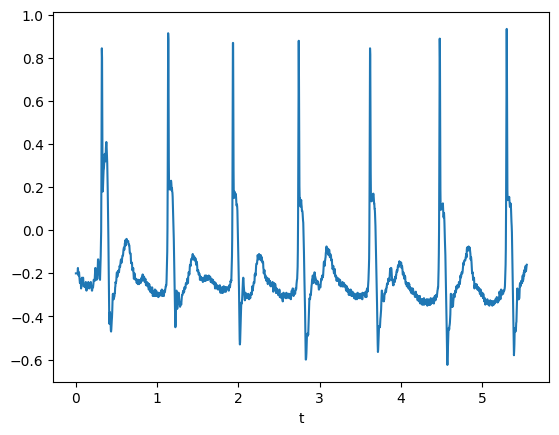

In [174]:
signal = pd.read_csv("data/102_V5.dat", header=None)
signal = signal.to_numpy().flatten()

print(f"{signal.shape=}")

fs = 360

plt.plot(np.arange(2000) / fs, signal[:2000])
plt.xlabel("t")
plt.show()

In [8]:
signal[:100]

array([-0.2  , -0.2  , -0.2  , -0.2  , -0.2  , -0.2  , -0.2  , -0.2  ,
       -0.19 , -0.175, -0.19 , -0.205, -0.21 , -0.2  , -0.195, -0.21 ,
       -0.23 , -0.235, -0.245, -0.235, -0.23 , -0.23 , -0.245, -0.27 ,
       -0.26 , -0.24 , -0.225, -0.22 , -0.225, -0.225, -0.225, -0.225,
       -0.22 , -0.235, -0.26 , -0.26 , -0.26 , -0.26 , -0.255, -0.255,
       -0.26 , -0.26 , -0.265, -0.25 , -0.24 , -0.255, -0.265, -0.28 ,
       -0.26 , -0.255, -0.25 , -0.245, -0.25 , -0.255, -0.245, -0.24 ,
       -0.25 , -0.245, -0.265, -0.27 , -0.25 , -0.25 , -0.245, -0.25 ,
       -0.255, -0.255, -0.24 , -0.245, -0.265, -0.26 , -0.27 , -0.28 ,
       -0.28 , -0.265, -0.265, -0.26 , -0.265, -0.255, -0.245, -0.23 ,
       -0.23 , -0.235, -0.23 , -0.235, -0.215, -0.19 , -0.175, -0.175,
       -0.195, -0.225, -0.225, -0.225, -0.23 , -0.215, -0.225, -0.225,
       -0.205, -0.165, -0.135, -0.135])

In [201]:
with open("data/102_attr.dat") as f:
    content = f.read()
    lines = content.split("\n")
    import re

    numbers = [int(n) for n in re.findall(r"\d+", content)]

GT_PEAKS = np.array(numbers)
GT_PEAKS.shape

(2187,)

Text(0.5, 1.0, 'lowpass')

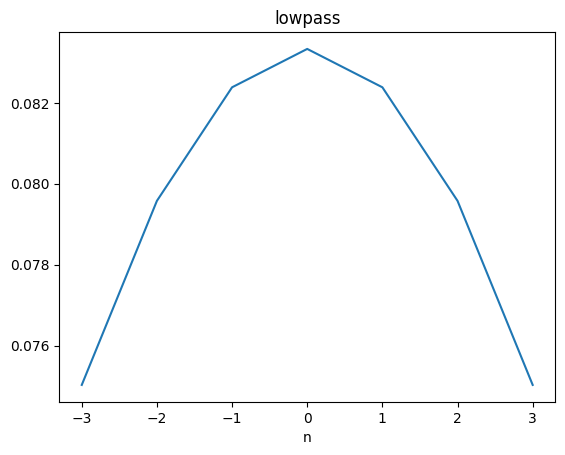

In [9]:
M = 3
fc = 15
fc_hat = fc / fs
lowpass = np.zeros(2*M + 1)

for i in range(2*M + 1):
    n = i - M
    if n == 0:
        lowpass[i] = 2 * fc_hat
    else:
        lowpass[i] = np.sin(2*np.pi*fc_hat*n) / (np.pi * n)

plt.plot(range(-M, M+1), lowpass)
plt.xlabel("n")
plt.title("lowpass")

Text(0.5, 1.0, 'highpass')

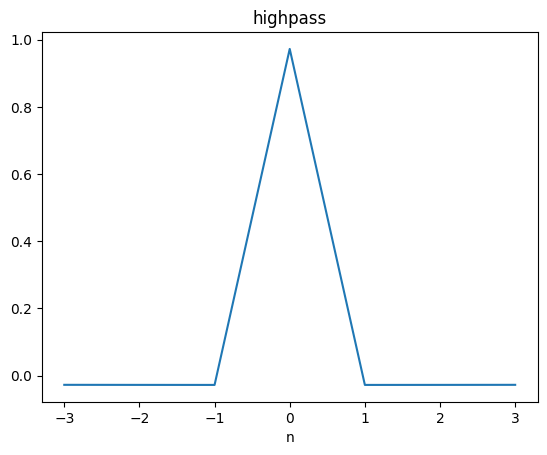

In [10]:
M = 3
fc = 5
fc_hat = fc / fs
highpass = np.zeros(2*M + 1)

for i in range(2*M + 1):
    n = i - M
    if n == 0:
        highpass[i] = 1 - 2*fc_hat
    else:
        highpass[i] = -np.sin(2*np.pi*fc_hat*n) / (np.pi * n)

plt.plot(range(-M, M+1), highpass)
plt.xlabel("n")
plt.title("highpass")

Text(0.5, 1.0, 'hamming window')

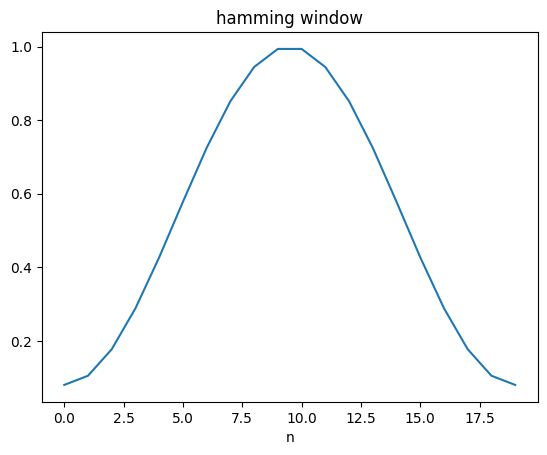

In [14]:
N = 20
hamming = np.zeros(N)
for n in range(N):
    hamming[n] = 0.54 - 0.46 * np.cos(2*np.pi*n/(N-1))

plt.plot(range(N), hamming)
plt.xlabel("n")
plt.title("hamming window")

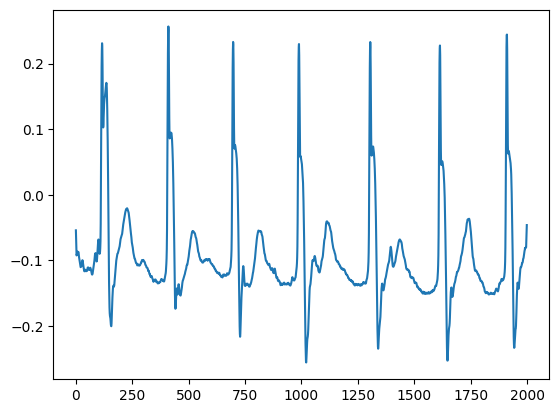

In [204]:
fragment = signal[:2000]
gt_fragment_peaks = GT_PEAKS[GT_PEAKS < fragment.shape[0]]

fragment = np.convolve(fragment, lowpass, mode="same")
fragment = np.convolve(fragment, highpass, mode="same")

plt.plot(fragment)

In [46]:
def differentiate(x):
    kernel = -np.array([-1, -2, 0, 2, 1]) / 8.0
    return np.convolve(x, kernel, mode="same")

def integrate(x, C):
    return np.convolve(x, np.ones(C), mode="same") / C

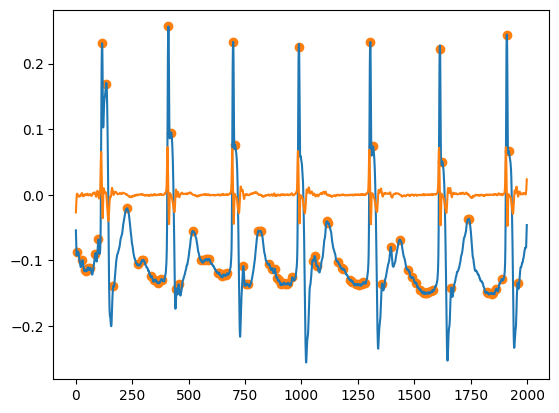

In [166]:
diff = differentiate(fragment)
zero_crossings = np.where((diff[:-1] > 0) & (diff[1:] < 0))[0]
plt.plot(fragment)
plt.plot(diff)
plt.scatter(zero_crossings, fragment[zero_crossings], color="tab:orange")

THRESHOLD_I1=0.025, THRESHOLD_I2=0.0125
SPKI=0.11637901171616064
THRESHOLD_I1=0.02909475292904016, THRESHOLD_I2=0.01454737646452008
SPKI=0.12294802799289781
THRESHOLD_I1=0.030737006998224452, THRESHOLD_I2=0.015368503499112226
SPKI=0.13965645316275552
THRESHOLD_I1=0.03491411329068888, THRESHOLD_I2=0.01745705664534444
SPKI=0.13402651518574005
THRESHOLD_I1=0.03350662879643501, THRESHOLD_I2=0.016753314398217506
SPKI=0.1464027328069384
THRESHOLD_I1=0.0366006832017346, THRESHOLD_I2=0.0183003416008673
SPKI=0.13758580499347253
THRESHOLD_I1=0.03439645124836813, THRESHOLD_I2=0.017198225624184067
SPKI=0.1485318183314279
THRESHOLD_I1=0.037132954582856974, THRESHOLD_I2=0.018566477291428487
SPKI=0.15907527819464667
THRESHOLD_I1=0.03976881954866167, THRESHOLD_I2=0.019884409774330834
SPKI=0.14838599332781588
THRESHOLD_I1=0.03709649833195397, THRESHOLD_I2=0.018548249165976985
SPKI=0.15767624413304937
THRESHOLD_I1=0.03941906103326234, THRESHOLD_I2=0.01970953051663117
SPKI=0.14427587145803084
THRESHOLD_I

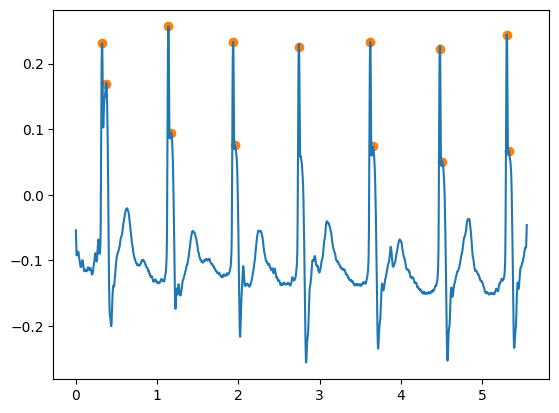

In [168]:
SPKI = 0.1
NPKI = 0.0
THRESHOLD_I1 = NPKI + 0.25 * (SPKI-NPKI)
THRESHOLD_I2 = 0.5 * THRESHOLD_I1
print(f"{THRESHOLD_I1=}, {THRESHOLD_I2=}")

signal_peaks = []
for peak_i in zero_crossings:
    value = fragment[peak_i]
    if value >= THRESHOLD_I1:
        # Signal peak
        SPKI = 0.125 * value + 0.875 * SPKI
        print(f"{SPKI=}")
        signal_peaks.append(peak_i)

        THRESHOLD_I1 = NPKI + 0.25 * (SPKI-NPKI)
        THRESHOLD_I2 = 0.5 * THRESHOLD_I1
        print(f"{THRESHOLD_I1=}, {THRESHOLD_I2=}")
    elif value >= THRESHOLD_I2:
        # Noise peak
        NPKI = 0.125 * value + 0.875 * NPKI
        print(f"{NPKI=}")

        THRESHOLD_I1 = NPKI + 0.25 * (SPKI-NPKI)
        THRESHOLD_I2 = 0.5 * THRESHOLD_I1
        print(f"{THRESHOLD_I1=}, {THRESHOLD_I2=}")

signal_peaks = np.array(signal_peaks, dtype=int)
plt.plot(np.arange(len(fragment))/fs, fragment)
plt.scatter(signal_peaks/fs, fragment[signal_peaks], color="tab:orange")
plt.show()

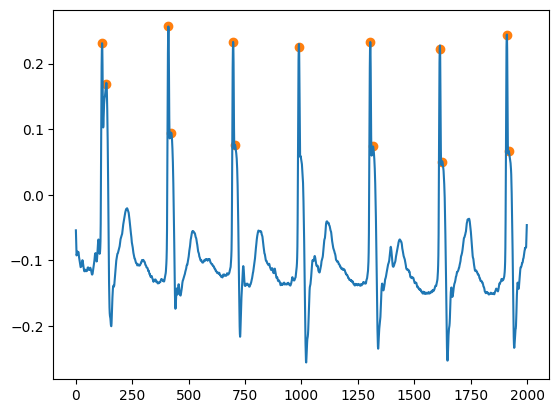

In [169]:
plt.plot(fragment)
plt.scatter(signal_peaks, fragment[signal_peaks], color="tab:orange")

In [170]:
MIN_DISTANCE_S = 0.2
MIN_DISTANCE_INDICES = fs * MIN_DISTANCE_S
print(f"{MIN_DISTANCE_INDICES=}")
too_close_peaks = np.where(signal_peaks[1:] - signal_peaks[:-1] < MIN_DISTANCE_INDICES)[0] + 1
while too_close_peaks.shape[0] > 0:
    signal_peaks = np.delete(signal_peaks, too_close_peaks[0])
    too_close_peaks = np.where(signal_peaks[1:] - signal_peaks[:-1] < MIN_DISTANCE_INDICES)[0] + 1

signal_peaks

MIN_DISTANCE_INDICES=72.0


array([ 116,  410,  697,  988, 1305, 1613, 1910])

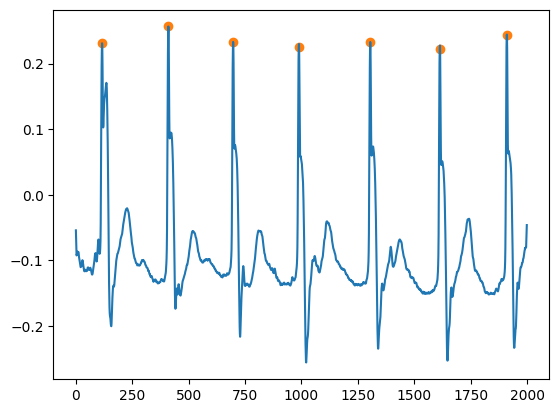

In [171]:
plt.plot(fragment)
plt.scatter(signal_peaks, fragment[signal_peaks], color="tab:orange")

In [210]:
def evaluate_detections(signal_peaks, gt_peaks):
    tolerance_samples = 50  # Indices

    unmatched_detected = list(signal_peaks)

    tp_errors_samples = []
    matched_gt = []
    matched_det = []

    for gt in gt_peaks:
        if len(unmatched_detected) == 0:
            break

        distances = np.abs(np.array(unmatched_detected) - gt)
        min_idx = np.argmin(distances)
        min_dist = distances[min_idx]

        if min_dist <= tolerance_samples:
            closest_det = unmatched_detected.pop(min_idx)

            tp_errors_samples.append(closest_det - gt)
            matched_gt.append(gt)
            matched_det.append(closest_det)

    TP = len(tp_errors_samples)

    FN = len(gt_peaks) - TP

    FP = len(signal_peaks) - TP

    errors_ms = (np.array(tp_errors_samples) / fs) * 1000.0

    if TP > 0:
        mae = np.mean(np.abs(errors_ms))
        sd = np.std(errors_ms)
    else:
        mae, sd = 0.0, 0.0

    metrics = {
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "MAE_ms": mae,
        "SD_ms": sd,
        "errors_ms": errors_ms,
        "matched_gt": np.array(matched_gt),
        "matched_det": np.array(matched_det),
    }

    return metrics

In [202]:
signal_peaks

array([ 116,  410,  697,  988, 1305, 1613, 1910])

In [205]:
gt_fragment_peaks

array([ 136,  410,  697,  989, 1305, 1614, 1911])

In [211]:
evaluate_detections(signal_peaks, gt_fragment_peaks)

{'TP': 7,
 'FP': 0,
 'FN': 0,
 'MAE_ms': 9.126984126984127,
 'SD_ms': 18.997951116802895,
 'errors_ms': array([-55.55555556,   0.        ,   0.        ,  -2.77777778,
          0.        ,  -2.77777778,  -2.77777778]),
 'matched_gt': array([ 136,  410,  697,  989, 1305, 1614, 1911]),
 'matched_det': array([ 116,  410,  697,  988, 1305, 1613, 1910])}